In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==============================
# LOAD DATASET
# ==============================

file_path = "heart_2020_cleaned.csv"

df = pd.read_csv(file_path)

# Display first five rows
print("First 5 rows of the dataset:")
display(df.head())

# Dataset shape
print("Dataset shape:")
print(df.shape)

First 5 rows of the dataset:


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No


Dataset shape:
(230703, 18)


In [2]:
# ==============================
# BASIC DATASET INFORMATION
# ==============================

print("Dataset information:")
df.info()

print("\nColumn names:")
print(df.columns.tolist())

print("\nStatistical summary:")
display(df.describe())

print("\nCategorical column summary:")
display(df.describe(include="object"))

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230703 entries, 0 to 230702
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      230703 non-null  object 
 1   BMI               230703 non-null  float64
 2   Smoking           230703 non-null  object 
 3   AlcoholDrinking   230703 non-null  object 
 4   Stroke            230703 non-null  object 
 5   PhysicalHealth    230703 non-null  int64  
 6   MentalHealth      230703 non-null  int64  
 7   DiffWalking       230703 non-null  object 
 8   Sex               230703 non-null  object 
 9   AgeCategory       230703 non-null  object 
 10  Race              230703 non-null  object 
 11  Diabetic          230703 non-null  object 
 12  PhysicalActivity  230703 non-null  object 
 13  GenHealth         230703 non-null  object 
 14  SleepTime         230703 non-null  int64  
 15  Asthma            230703 non-null  object 
 16 

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,230703.000000,230703.000000,230703.000000,230703.000000
mean,28.304489,3.327451,3.883040,7.102630
std,6.349549,7.898767,7.928839,1.439556
min,12.020000,0.000000,0.000000,1.000000
25%,24.015000,0.000000,0.000000,6.000000
50%,27.320000,0.000000,0.000000,7.000000
75%,31.380000,2.000000,3.000000,8.000000
max,94.850000,30.000000,30.000000,24.000000



Categorical column summary:


,HeartDisease,Smoking,AlcoholDrinking,Stroke,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,Asthma,KidneyDisease,SkinCancer
count,230703,230703,230703,230703,230703,230703,230703,230703,230703,230703,230703,230703,230702,230702
unique,2,2,2,2,2,2,13,6,4,2,5,2,2,2
top,No,No,No,No,No,Female,65-69,White,No,Yes,Very good,No,No,No
freq,210915,134226,214705,221909,198665,121202,24720,177823,194676,179087,82695,200354,222212,209094


In [3]:
# ==============================
# CHECK NULL VALUES
# ==============================

print("Missing values in each column:")
null_values = df.isnull().sum()
print(null_values)

print("\nTotal missing values:")
print(df.isnull().sum().sum())

# ==============================
# CHECK DUPLICATES
# ==============================

duplicate_count = df.duplicated().sum()
print("\nNumber of duplicate rows:")
print(duplicate_count)

Missing values in each column:
HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       1
SkinCancer          1
dtype: int64

Total missing values:
2

Number of duplicate rows:
10524


In [4]:
# ==============================
# CLEAN COLUMN NAMES
# ==============================

df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")

print("Updated column names:")
print(df.columns.tolist())

Updated column names:
['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer']


In [5]:
# ==============================
# REMOVE DUPLICATES
# ==============================

print("Shape before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Shape before removing duplicates: (230703, 18)
Shape after removing duplicates: (220179, 18)
Remaining duplicate rows: 0


In [6]:
# ==============================
# TARGET COLUMN DISTRIBUTION
# ==============================

target_col = "HeartDisease"

print("Target column value counts:")
print(df[target_col].value_counts())

print("\nTarget column percentage:")
print(df[target_col].value_counts(normalize=True) * 100)

Target column value counts:
HeartDisease
No     200455
Yes     19724
Name: count, dtype: int64

Target column percentage:
HeartDisease
No     91.041834
Yes     8.958166
Name: proportion, dtype: float64


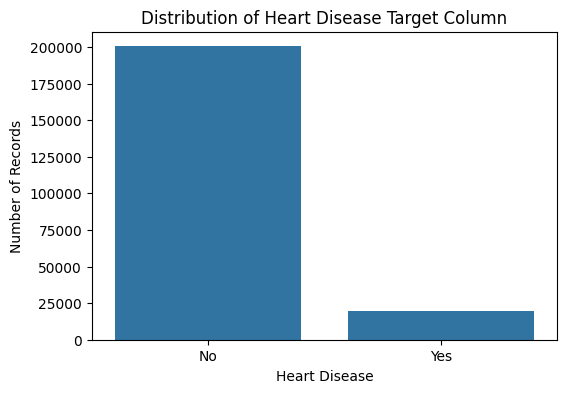

In [7]:
# ==============================
# TARGET DISTRIBUTION PLOT
# ==============================

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="HeartDisease")
plt.title("Distribution of Heart Disease Target Column")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Records")
plt.show()

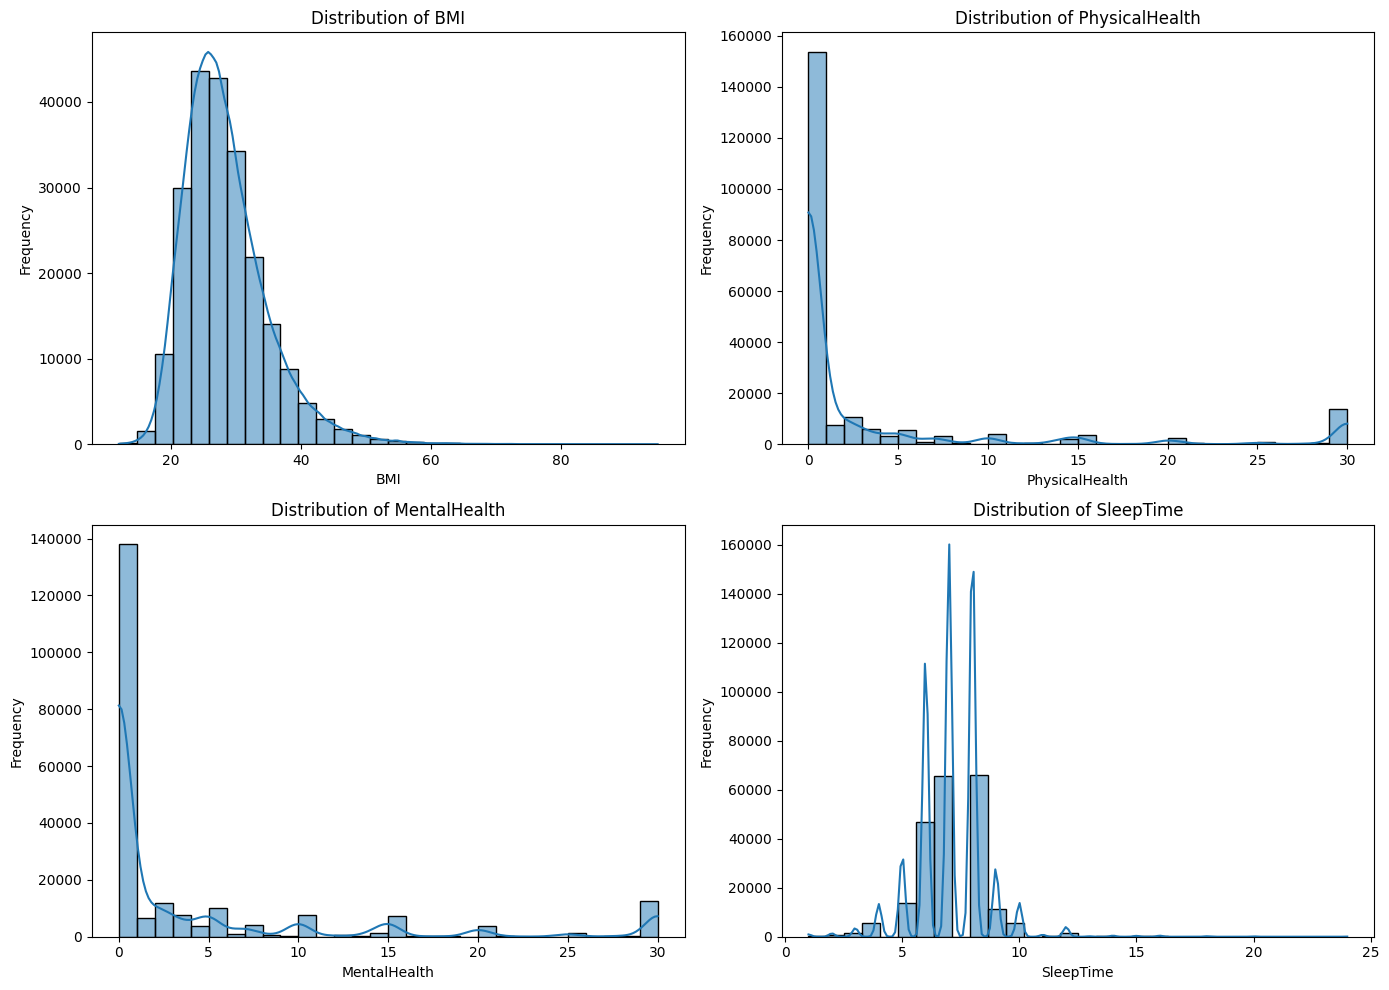

In [10]:
# ============================================================
# CELL 8: NUMERICAL FEATURE DISTRIBUTIONS
# ============================================================

num_cols = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]

plt.figure(figsize=(14, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

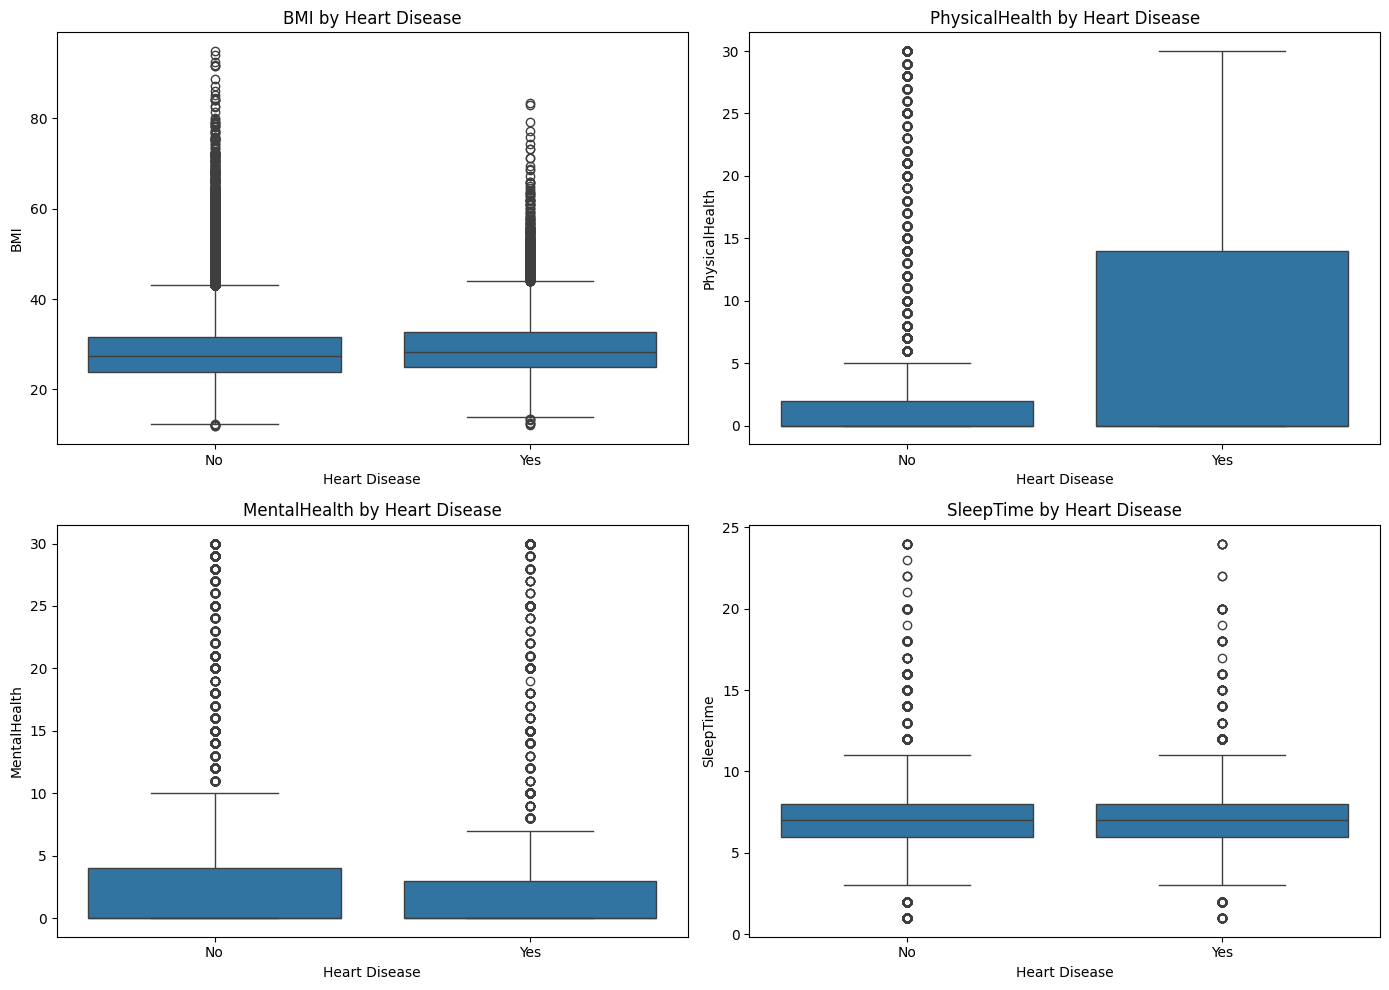

In [11]:
# ============================================================
# CELL 9: NUMERICAL FEATURES BY HEART DISEASE
# ============================================================

num_cols = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]

plt.figure(figsize=(14, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        data=df,
        x="HeartDisease",
        y=col,
        order=["No", "Yes"]
    )
    plt.title(f"{col} by Heart Disease")
    plt.xlabel("Heart Disease")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

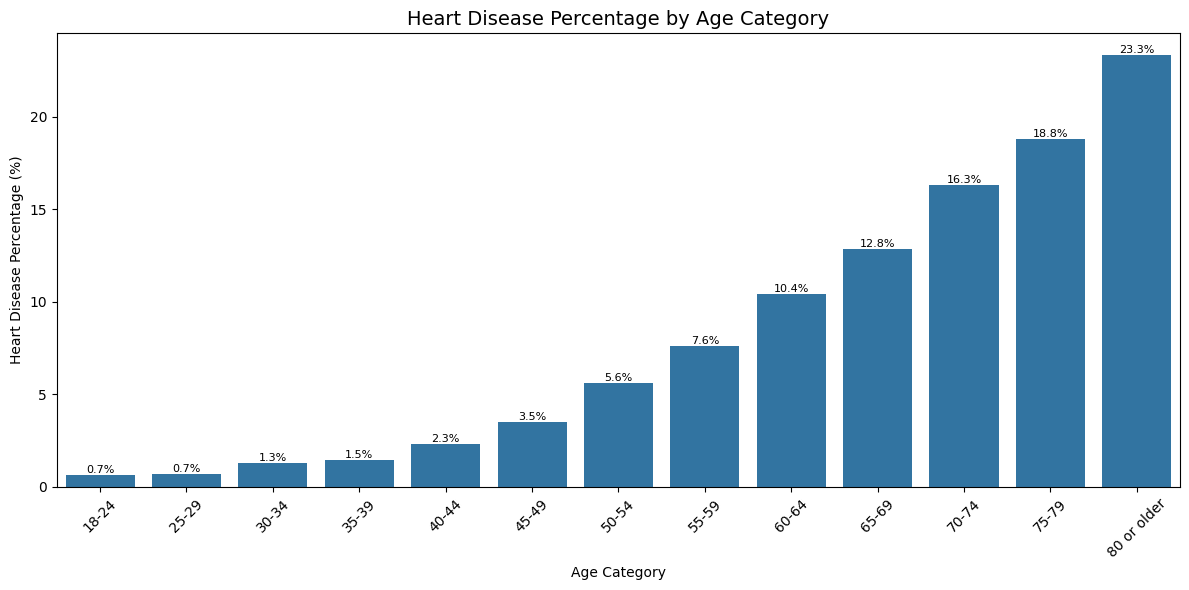

,AgeCategory,HeartDiseasePercentage
0,18-24,0.650159
1,25-29,0.715442
2,30-34,1.279877
3,35-39,1.480065
4,40-44,2.318841
5,45-49,3.484203
6,50-54,5.631034
7,55-59,7.610837
8,60-64,10.397380
9,65-69,12.840484


In [12]:
# ============================================================
# CELL 10: HEART DISEASE PERCENTAGE BY AGE CATEGORY
# ============================================================

age_order = [
    "18-24", "25-29", "30-34", "35-39", "40-44",
    "45-49", "50-54", "55-59", "60-64", "65-69",
    "70-74", "75-79", "80 or older"
]

age_heart_rate = (
    df.groupby("AgeCategory")["HeartDisease"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reindex(age_order)
    .reset_index()
)

age_heart_rate.columns = ["AgeCategory", "HeartDiseasePercentage"]

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=age_heart_rate,
    x="AgeCategory",
    y="HeartDiseasePercentage"
)

plt.title("Heart Disease Percentage by Age Category", fontsize=14)
plt.xlabel("Age Category")
plt.ylabel("Heart Disease Percentage (%)")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8)

plt.tight_layout()
plt.show()

display(age_heart_rate)

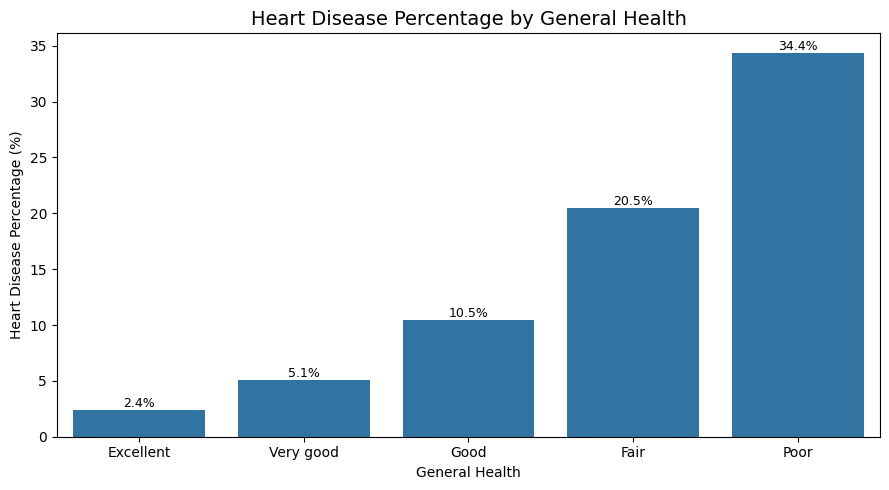

,GenHealth,HeartDiseasePercentage
0,Excellent,2.371416
1,Very good,5.094710
2,Good,10.489850
3,Fair,20.506659
4,Poor,34.393564


In [13]:
# ============================================================
# CELL 11: HEART DISEASE PERCENTAGE BY GENERAL HEALTH
# ============================================================

genhealth_order = ["Excellent", "Very good", "Good", "Fair", "Poor"]

genhealth_rate = (
    df.groupby("GenHealth")["HeartDisease"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reindex(genhealth_order)
    .reset_index()
)

genhealth_rate.columns = ["GenHealth", "HeartDiseasePercentage"]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=genhealth_rate,
    x="GenHealth",
    y="HeartDiseasePercentage"
)

plt.title("Heart Disease Percentage by General Health", fontsize=14)
plt.xlabel("General Health")
plt.ylabel("Heart Disease Percentage (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9)

plt.tight_layout()
plt.show()

display(genhealth_rate)

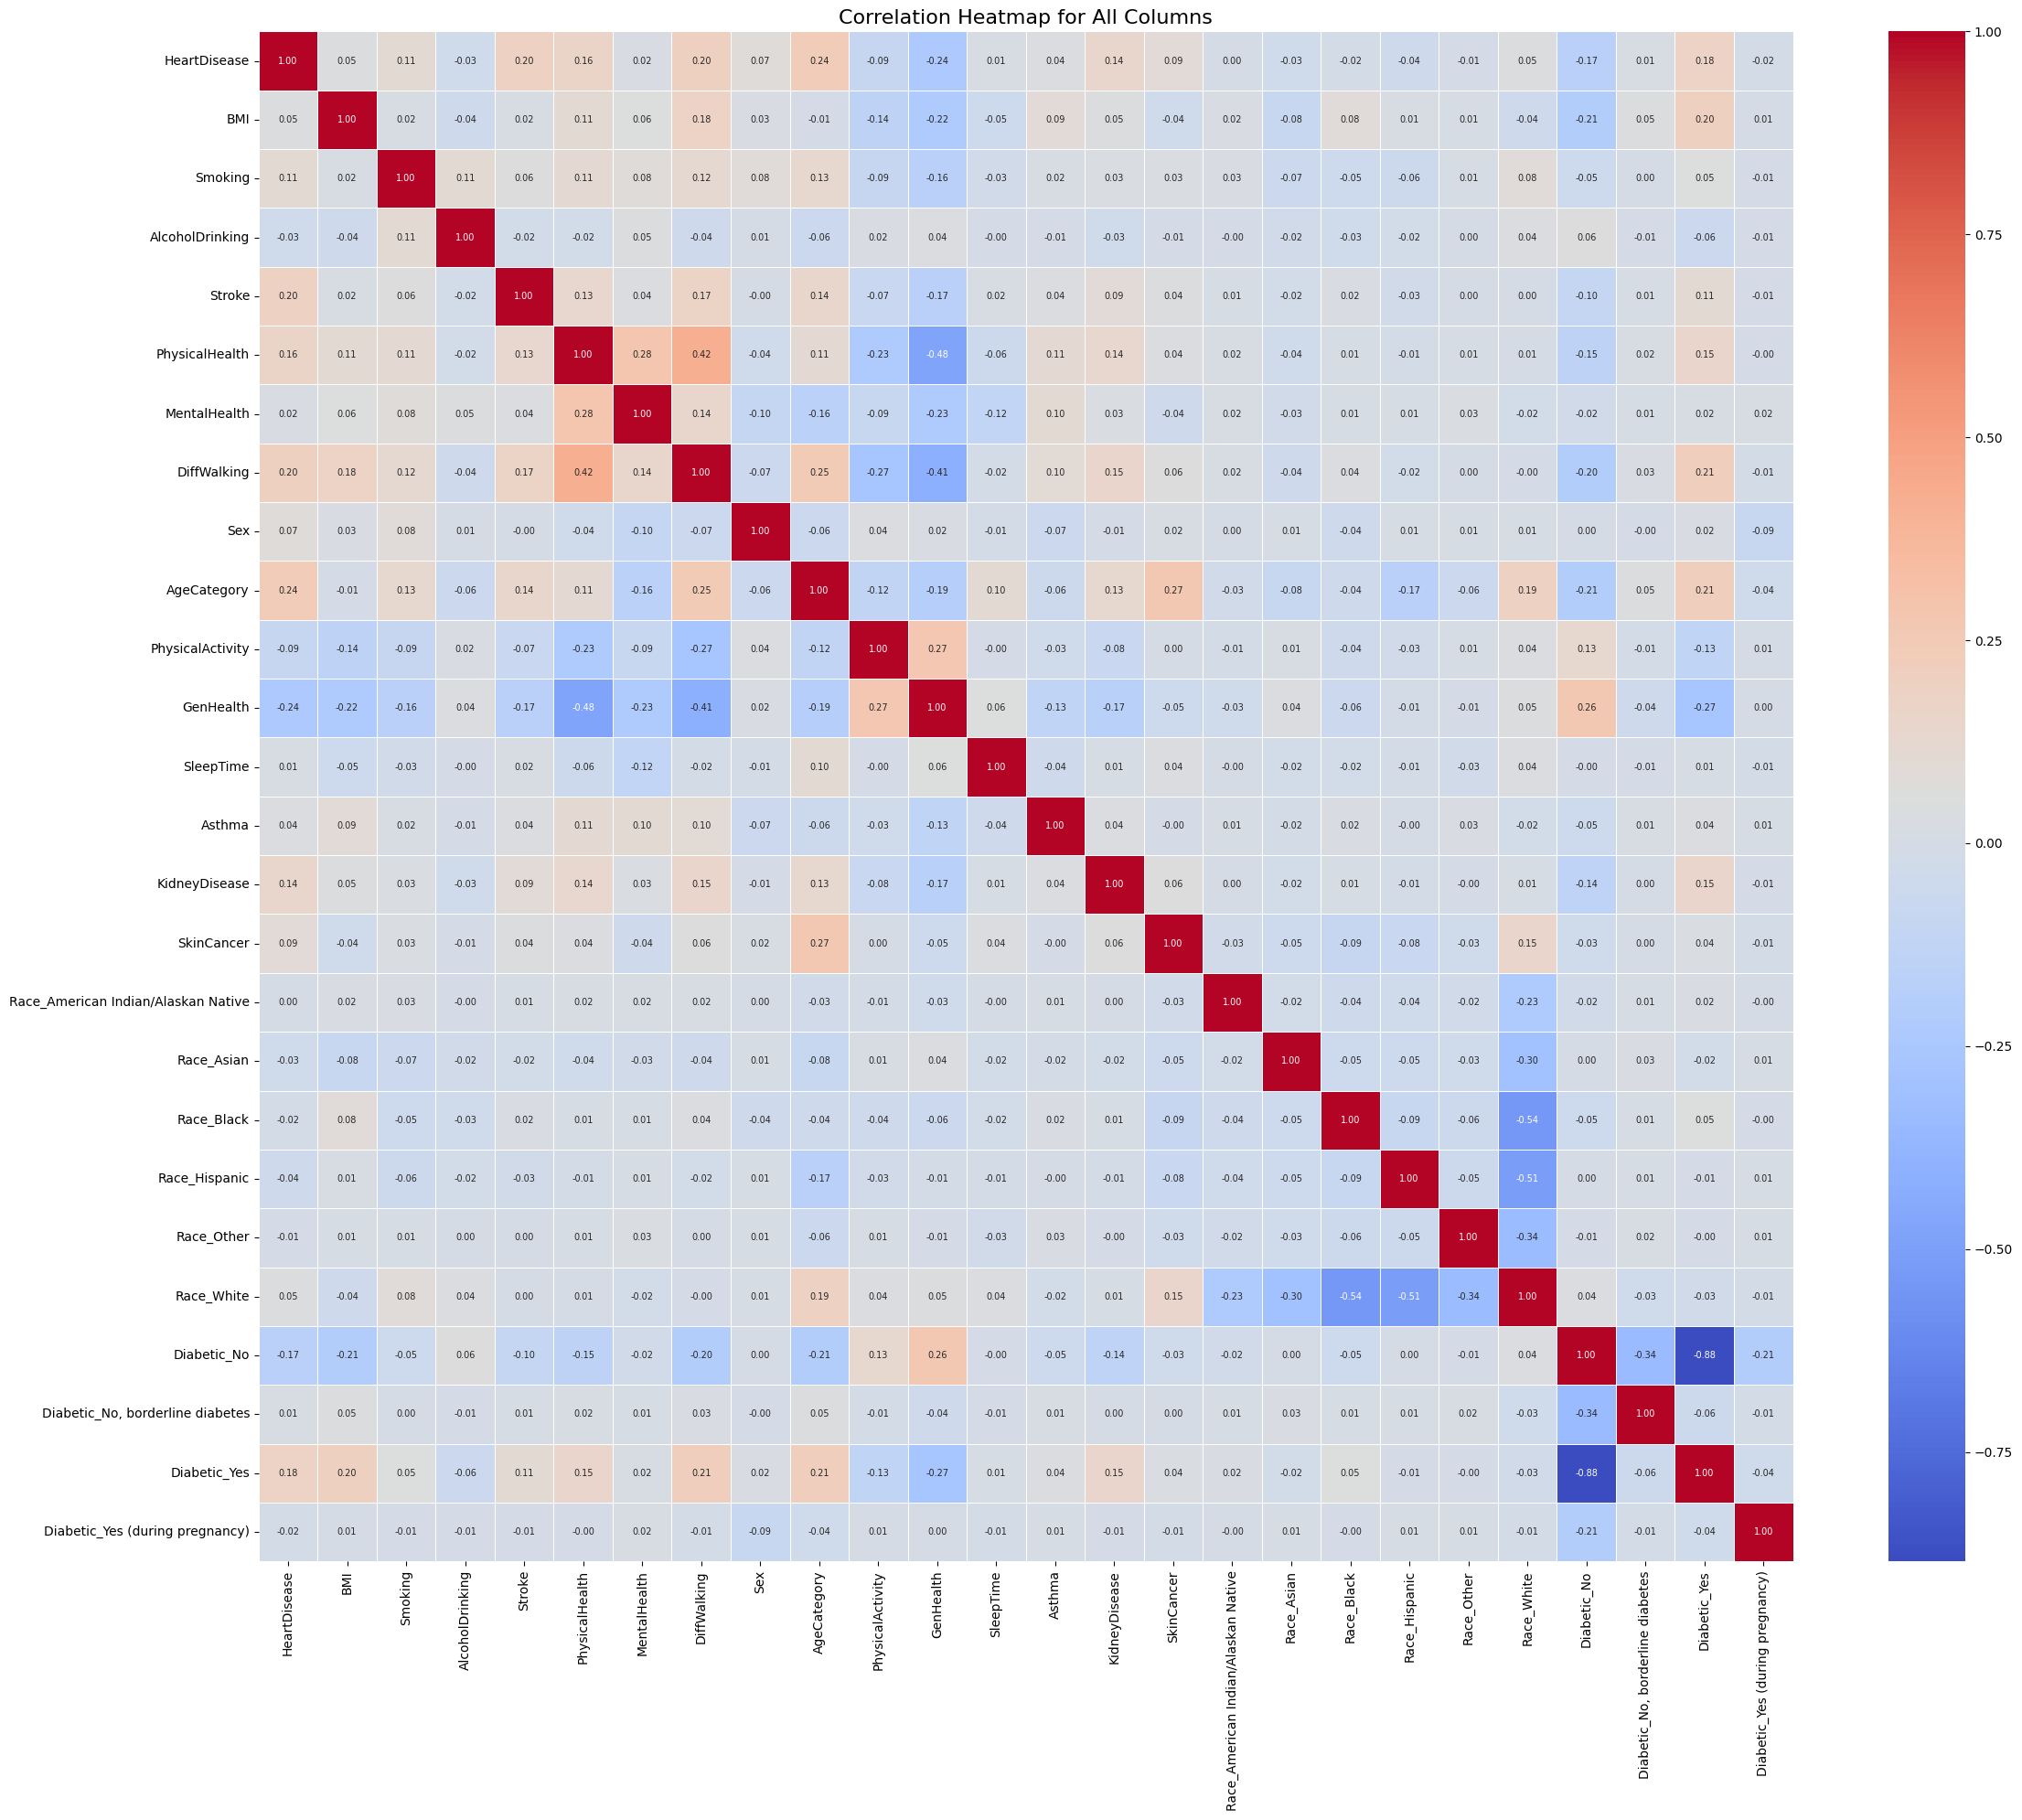

In [15]:
# ============================================================
# CORRELATION HEATMAP FOR ALL COLUMNS
# ============================================================
# This cell creates a correlation heatmap using all columns.
# Categorical columns are encoded safely.
# Original df is not changed.
# ============================================================

# Create copy
heatmap_df = df.copy()

# Remove extra spaces from text values
for col in heatmap_df.select_dtypes(include="object").columns:
    heatmap_df[col] = heatmap_df[col].astype(str).str.strip()

# Encode Yes/No columns
yes_no_cols = [
    "HeartDisease", "Smoking", "AlcoholDrinking", "Stroke",
    "DiffWalking", "PhysicalActivity", "Asthma",
    "KidneyDisease", "SkinCancer"
]

for col in yes_no_cols:
    heatmap_df[col] = heatmap_df[col].map({"No": 0, "Yes": 1})

# Encode Sex
heatmap_df["Sex"] = heatmap_df["Sex"].map({"Female": 0, "Male": 1})

# Encode AgeCategory in correct order
age_map = {
    "18-24": 1,
    "25-29": 2,
    "30-34": 3,
    "35-39": 4,
    "40-44": 5,
    "45-49": 6,
    "50-54": 7,
    "55-59": 8,
    "60-64": 9,
    "65-69": 10,
    "70-74": 11,
    "75-79": 12,
    "80 or older": 13
}

heatmap_df["AgeCategory"] = heatmap_df["AgeCategory"].map(age_map)

# Encode GenHealth in ordered form
# Higher value means better general health
genhealth_map = {
    "Poor": 1,
    "Fair": 2,
    "Good": 3,
    "Very good": 4,
    "Excellent": 5
}

heatmap_df["GenHealth"] = heatmap_df["GenHealth"].map(genhealth_map)

# One-hot encode remaining categorical columns
heatmap_df = pd.get_dummies(
    heatmap_df,
    columns=["Race", "Diabetic"],
    drop_first=False,
    dtype=int
)

# Convert all columns to numeric safely
heatmap_df = heatmap_df.apply(pd.to_numeric, errors="coerce")

# Fill any remaining NaN values with 0
heatmap_df = heatmap_df.fillna(0)

# Create correlation matrix
corr_matrix = heatmap_df.corr()

# Plot heatmap
plt.figure(figsize=(24, 20))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7}
)

plt.title("Correlation Heatmap for All Columns", fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# CELL 13: PREPARE DATA AND LABEL ENCODING
# ============================================================
# This cell prepares the dataset for machine learning.
# Categorical columns are converted into numeric labels.
# Target column HeartDisease is converted into 0 and 1.
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Create a copy for modelling
model_df = df.copy()

# Remove extra spaces from categorical text values
for col in model_df.select_dtypes(include="object").columns:
    model_df[col] = model_df[col].astype(str).str.strip()

# Encode target column manually
model_df["HeartDisease"] = model_df["HeartDisease"].map({
    "No": 0,
    "Yes": 1
})

# Label encode remaining categorical input columns
label_encoders = {}

categorical_cols = model_df.select_dtypes(include="object").columns

for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    label_encoders[col] = le

print("Label encoding completed successfully.")
print("Dataset shape after encoding:", model_df.shape)

# Display first five rows
display(model_df.head())

# Check target distribution after encoding
print("\nTarget distribution after encoding:")
print(model_df["HeartDisease"].value_counts())

Label encoding completed successfully.
Dataset shape after encoding: (220179, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3,30,0,0,7,5,2,1,4,5,1,0,1
1,0,20.34,0,0,1,0,0,0,0,12,5,0,1,4,7,0,0,0
2,0,26.58,1,0,0,20,30,0,1,9,5,2,1,1,8,1,0,0
3,0,24.21,0,0,0,0,0,0,0,11,5,0,0,2,6,0,0,1
4,0,23.71,0,0,0,28,0,1,0,4,5,0,1,4,8,0,0,0



Target distribution after encoding:
HeartDisease
0    200455
1     19724
Name: count, dtype: int64


In [17]:
# ============================================================
# CELL 14: TRAIN-TEST SPLIT
# ============================================================
# The dataset is split into training and testing sets.
# Stratify is used to keep the same class ratio in train and test.
# ============================================================

from sklearn.model_selection import train_test_split

# Separate input features and target
X = model_df.drop("HeartDisease", axis=1)
y = model_df["HeartDisease"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution before balancing:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training feature shape: (176143, 17)
Testing feature shape: (44036, 17)

Training target distribution before balancing:
HeartDisease
0    160364
1     15779
Name: count, dtype: int64

Testing target distribution:
HeartDisease
0    40091
1     3945
Name: count, dtype: int64


In [18]:
# ============================================================
# CELL 15: BALANCE TRAINING DATA USING UNDERSAMPLING
# ============================================================
# SMOTE is not used.
# The majority class is reduced to match the minority class.
# This is done only on the training data to avoid data leakage.
# ============================================================

from sklearn.utils import resample

# Combine X_train and y_train for balancing
train_data = X_train.copy()
train_data["HeartDisease"] = y_train.values

# Separate majority and minority classes
majority_class = train_data[train_data["HeartDisease"] == 0]
minority_class = train_data[train_data["HeartDisease"] == 1]

print("Before balancing:")
print("Majority class records:", len(majority_class))
print("Minority class records:", len(minority_class))

# Downsample majority class
majority_downsampled = resample(
    majority_class,
    replace=False,
    n_samples=len(minority_class),
    random_state=42
)

# Combine minority class with downsampled majority class
balanced_train_data = pd.concat([majority_downsampled, minority_class])

# Shuffle balanced data
balanced_train_data = balanced_train_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Separate balanced features and target
X_train_balanced = balanced_train_data.drop("HeartDisease", axis=1)
y_train_balanced = balanced_train_data["HeartDisease"]

print("\nAfter balancing:")
print(y_train_balanced.value_counts())

print("\nBalanced training feature shape:", X_train_balanced.shape)
print("Balanced training target shape:", y_train_balanced.shape)

Before balancing:
Majority class records: 160364
Minority class records: 15779

After balancing:
HeartDisease
0    15779
1    15779
Name: count, dtype: int64

Balanced training feature shape: (31558, 17)
Balanced training target shape: (31558,)


In [19]:
# ============================================================
# CELL 16: FEATURE SCALING
# ============================================================
# StandardScaler is fitted only on balanced training data.
# The same scaler is then applied to the test data.
# Scaling is especially important for SVM.
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on balanced training data only
X_train_scaled = scaler.fit_transform(X_train_balanced)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaling completed successfully.
Scaled training shape: (31558, 17)
Scaled testing shape: (44036, 17)


In [20]:
# ============================================================
# CELL 17: MODEL EVALUATION FUNCTION
# ============================================================
# This function prints accuracy, precision, recall, F1-score,
# ROC-AUC, classification report, confusion matrix, and ROC curve.
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

def evaluate_model(model, X_test_data, y_test_data, model_name):
    # Predictions
    y_pred = model.predict(X_test_data)

    # ROC score values
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_data)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_data)
    else:
        y_score = y_pred

    # Metrics
    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred)
    recall = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)
    roc_auc = roc_auc_score(y_test_data, y_score)

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    print("\nClassification Report:")
    print(classification_report(y_test_data, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test_data, y_pred)

    plt.figure(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Heart Disease", "Heart Disease"]
    )
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # ROC Curve
    plt.figure(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test_data, y_score)
    plt.title(f"ROC Curve - {model_name}")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    }

Basic Support Vector Machine
Accuracy : 0.7264
Precision: 0.2188
Recall   : 0.7992
F1-score : 0.3435
ROC-AUC  : 0.8236

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.72      0.83     40091
           1       0.22      0.80      0.34      3945

    accuracy                           0.73     44036
   macro avg       0.60      0.76      0.59     44036
weighted avg       0.91      0.73      0.78     44036



<Figure size 600x500 with 0 Axes>

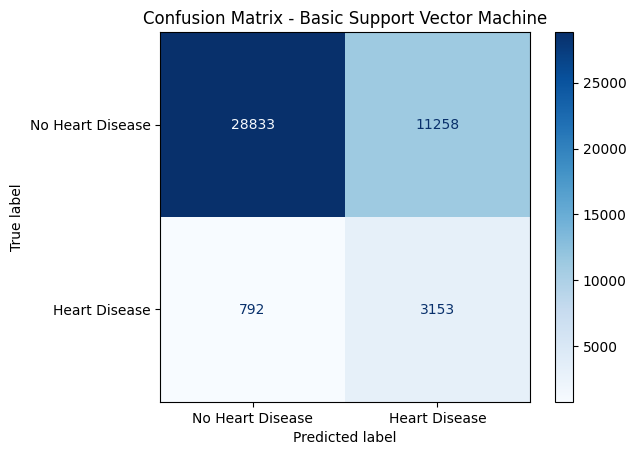

<Figure size 600x500 with 0 Axes>

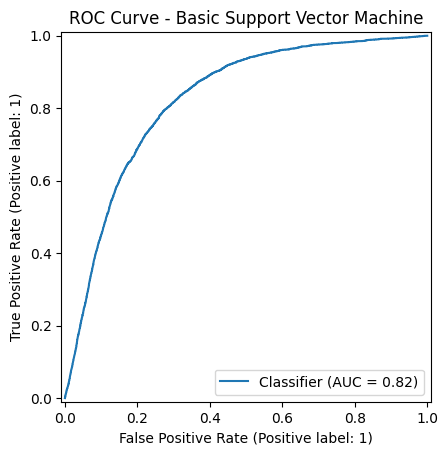

In [21]:
# ============================================================
# CELL 18: BASIC SUPPORT VECTOR MACHINE MODEL
# ============================================================

from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train_balanced)

svm_results = evaluate_model(
    svm_model,
    X_test_scaled,
    y_test,
    "Basic Support Vector Machine"
)

Basic Decision Tree
Accuracy : 0.6715
Precision: 0.1638
Recall   : 0.6494
F1-score : 0.2616
ROC-AUC  : 0.6617

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.67      0.79     40091
           1       0.16      0.65      0.26      3945

    accuracy                           0.67     44036
   macro avg       0.56      0.66      0.53     44036
weighted avg       0.88      0.67      0.74     44036



<Figure size 600x500 with 0 Axes>

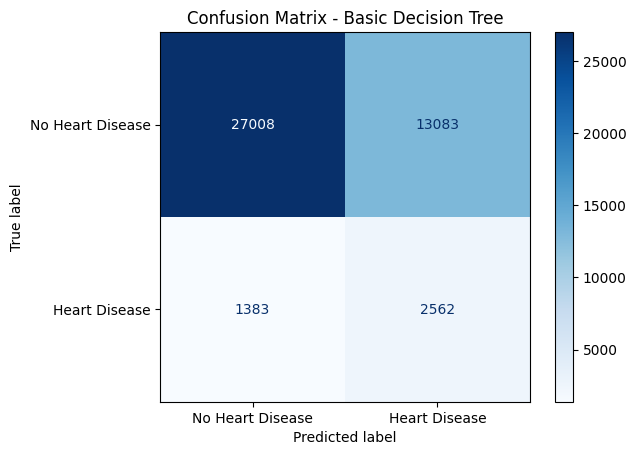

<Figure size 600x500 with 0 Axes>

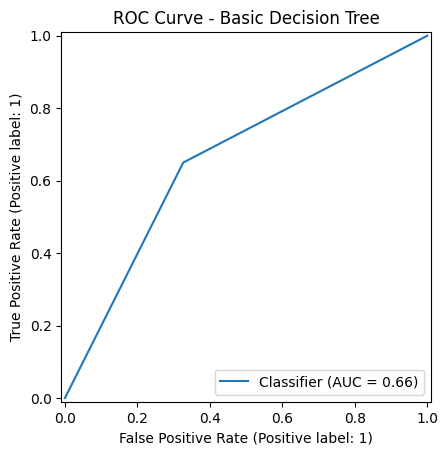

In [22]:
# ============================================================
# CELL 19: BASIC DECISION TREE MODEL
# ============================================================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_scaled, y_train_balanced)

dt_results = evaluate_model(
    dt_model,
    X_test_scaled,
    y_test,
    "Basic Decision Tree"
)

Basic XGBoost
Accuracy : 0.73
Precision: 0.2197
Recall   : 0.7894
F1-score : 0.3437
ROC-AUC  : 0.8323

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.72      0.83     40091
           1       0.22      0.79      0.34      3945

    accuracy                           0.73     44036
   macro avg       0.60      0.76      0.59     44036
weighted avg       0.90      0.73      0.79     44036



<Figure size 600x500 with 0 Axes>

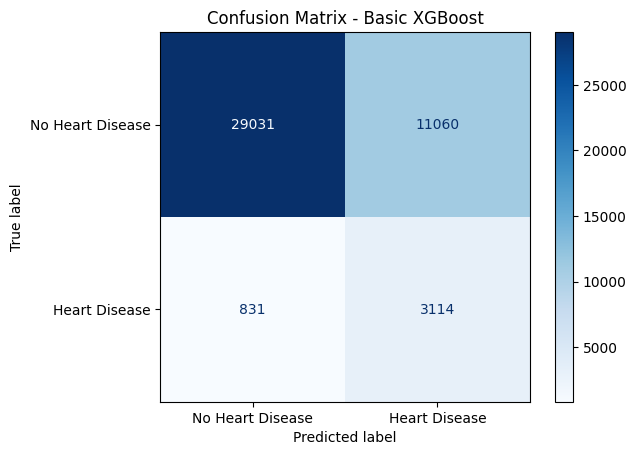

<Figure size 600x500 with 0 Axes>

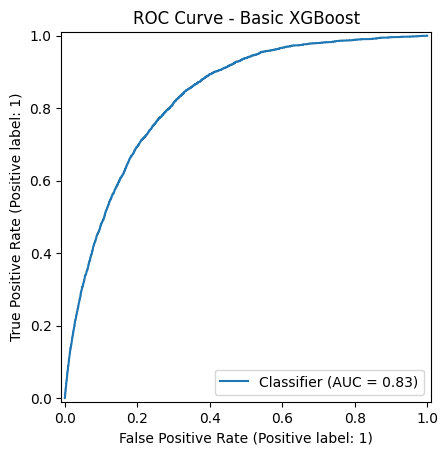

In [23]:
# ============================================================
# CELL 20: BASIC XGBOOST MODEL
# ============================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_scaled, y_train_balanced)

xgb_results = evaluate_model(
    xgb_model,
    X_test_scaled,
    y_test,
    "Basic XGBoost"
)

In [24]:
# ============================================================
# CELL 21: BASIC MODEL COMPARISON
# ============================================================

basic_results_df = pd.DataFrame([
    svm_results,
    dt_results,
    xgb_results
])

display(basic_results_df)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Basic Support Vector Machine,0.726360,0.218791,0.799240,0.343539,0.823612
1,Basic Decision Tree,0.671496,0.163758,0.649430,0.261562,0.661693
2,Basic XGBoost,0.729971,0.219698,0.789354,0.343728,0.832256


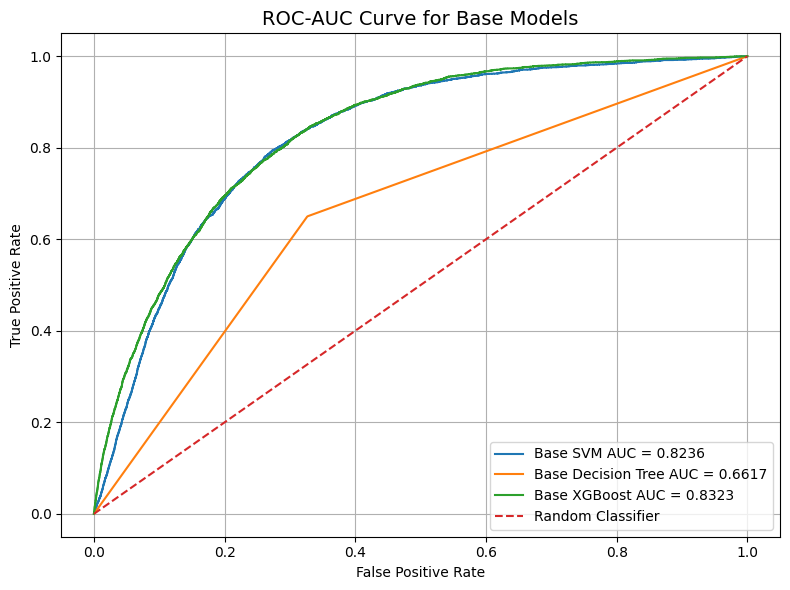

In [32]:
# ============================================================
# ROC-AUC CURVE FOR BASE MODELS
# ============================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Function to get prediction scores for ROC curve
def get_prediction_scores(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X_data)
    else:
        return model.predict(X_data)

# Base models dictionary
base_models = {
    "Base SVM": svm_model,
    "Base Decision Tree": dt_model,
    "Base XGBoost": xgb_model
}

plt.figure(figsize=(8, 6))

for model_name, model in base_models.items():
    y_score = get_prediction_scores(model, X_test_scaled)

    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} AUC = {roc_auc:.4f}"
    )

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC-AUC Curve for Base Models", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# CELL 22: IMPORT HYPERPARAMETER TUNING LIBRARY
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best SVM Parameters:
{'kernel': 'linear', 'gamma': 'scale', 'C': 0.1}
Best SVM ROC-AUC Score:
0.8248365250716523
Tuned Support Vector Machine
Accuracy : 0.7226
Precision: 0.2149
Recall   : 0.7901
F1-score : 0.3379
ROC-AUC  : 0.8262

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.72      0.82     40091
           1       0.21      0.79      0.34      3945

    accuracy                           0.72     44036
   macro avg       0.59      0.75      0.58     44036
weighted avg       0.90      0.72      0.78     44036



<Figure size 600x500 with 0 Axes>

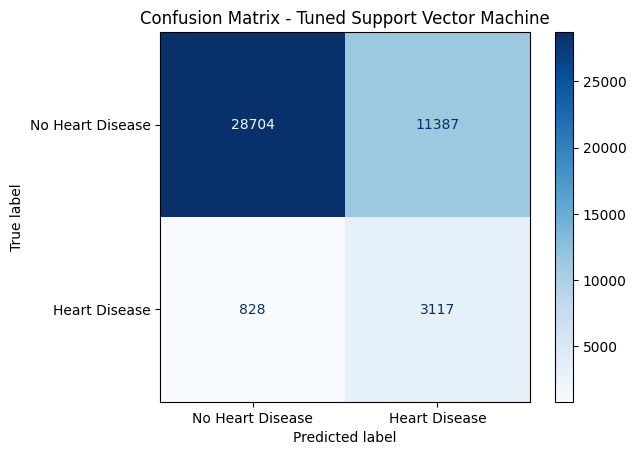

<Figure size 600x500 with 0 Axes>

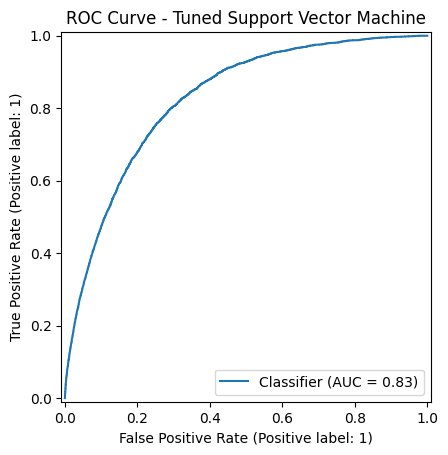

In [26]:
# ============================================================
# CELL 23: SVM HYPERPARAMETER TUNING
# ============================================================

svm_param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

svm_search = RandomizedSearchCV(
    estimator=SVC(random_state=42),
    param_distributions=svm_param_grid,
    n_iter=5,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

svm_search.fit(X_train_scaled, y_train_balanced)

print("Best SVM Parameters:")
print(svm_search.best_params_)

print("Best SVM ROC-AUC Score:")
print(svm_search.best_score_)

best_svm = svm_search.best_estimator_

tuned_svm_results = evaluate_model(
    best_svm,
    X_test_scaled,
    y_test,
    "Tuned Support Vector Machine"
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Decision Tree Parameters:
{'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 5, 'criterion': 'gini'}
Best Decision Tree ROC-AUC Score:
0.8038180781837868
Tuned Decision Tree
Accuracy : 0.7142
Precision: 0.2086
Recall   : 0.784
F1-score : 0.3296
ROC-AUC  : 0.8077

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.71      0.82     40091
           1       0.21      0.78      0.33      3945

    accuracy                           0.71     44036
   macro avg       0.59      0.75      0.57     44036
weighted avg       0.90      0.71      0.77     44036



<Figure size 600x500 with 0 Axes>

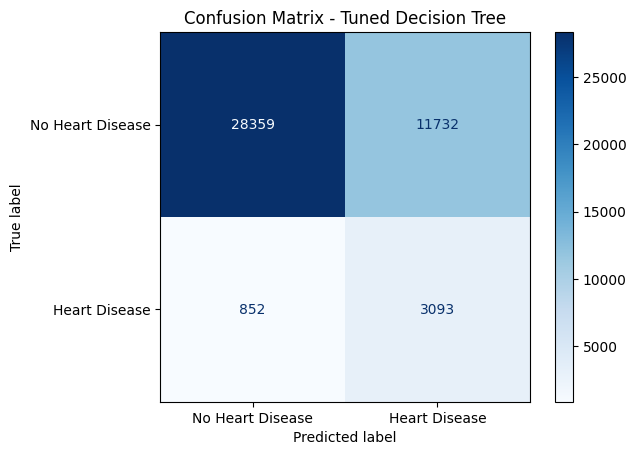

<Figure size 600x500 with 0 Axes>

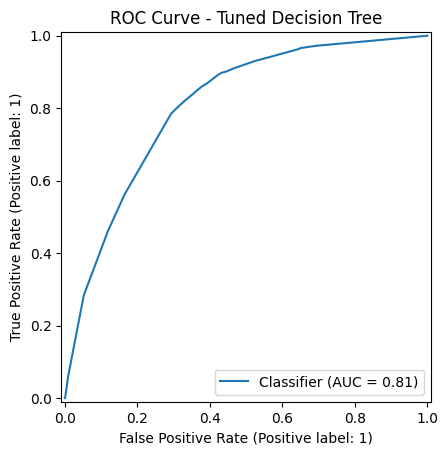

In [27]:
# ============================================================
# CELL 24: DECISION TREE HYPERPARAMETER TUNING
# ============================================================

dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None]
}

dt_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=dt_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

dt_search.fit(X_train_scaled, y_train_balanced)

print("Best Decision Tree Parameters:")
print(dt_search.best_params_)

print("Best Decision Tree ROC-AUC Score:")
print(dt_search.best_score_)

best_dt = dt_search.best_estimator_

tuned_dt_results = evaluate_model(
    best_dt,
    X_test_scaled,
    y_test,
    "Tuned Decision Tree"
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGBoost Parameters:
{'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
Best XGBoost ROC-AUC Score:
0.8397066391424964
Tuned XGBoost
Accuracy : 0.7371
Precision: 0.2262
Recall   : 0.7995
F1-score : 0.3527
ROC-AUC  : 0.8421

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.73      0.84     40091
           1       0.23      0.80      0.35      3945

    accuracy                           0.74     44036
   macro avg       0.60      0.77      0.59     44036
weighted avg       0.91      0.74      0.79     44036



<Figure size 600x500 with 0 Axes>

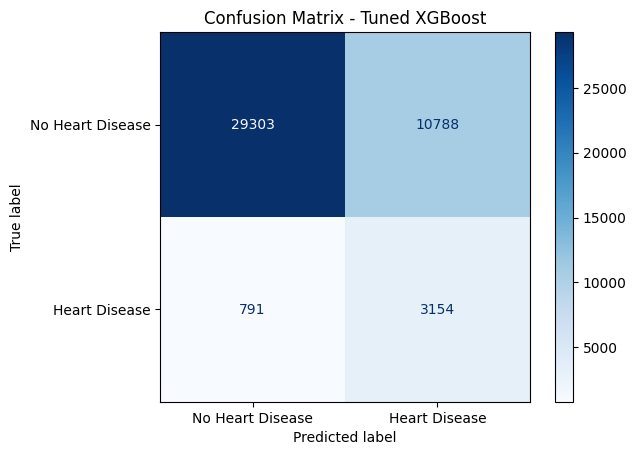

<Figure size 600x500 with 0 Axes>

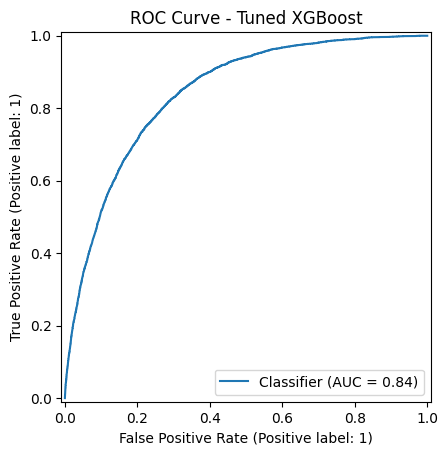

In [28]:
# ============================================================
# CELL 25: XGBOOST HYPERPARAMETER TUNING
# ============================================================

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train_scaled, y_train_balanced)

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

print("Best XGBoost ROC-AUC Score:")
print(xgb_search.best_score_)

best_xgb = xgb_search.best_estimator_

tuned_xgb_results = evaluate_model(
    best_xgb,
    X_test_scaled,
    y_test,
    "Tuned XGBoost"
)

In [29]:
# ============================================================
# CELL 26: FINAL MODEL COMPARISON TABLE
# ============================================================

final_results_df = pd.DataFrame([
    svm_results,
    dt_results,
    xgb_results,
    tuned_svm_results,
    tuned_dt_results,
    tuned_xgb_results
])

display(final_results_df)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Basic Support Vector Machine,0.726360,0.218791,0.799240,0.343539,0.823612
1,Basic Decision Tree,0.671496,0.163758,0.649430,0.261562,0.661693
2,Basic XGBoost,0.729971,0.219698,0.789354,0.343728,0.832256
3,Tuned Support Vector Machine,0.722613,0.214906,0.790114,0.337904,0.826187
4,Tuned Decision Tree,0.714234,0.208634,0.784030,0.329568,0.807698
5,Tuned XGBoost,0.737056,0.226223,0.799493,0.352658,0.842131


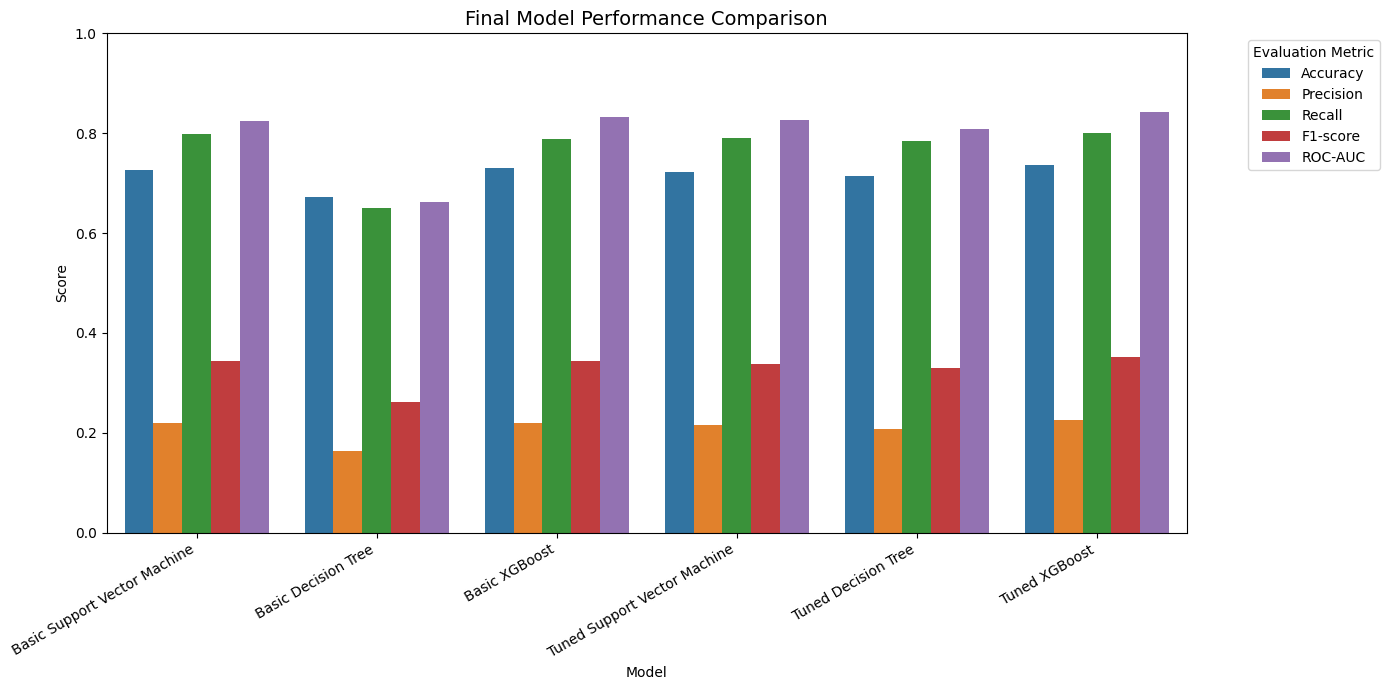

In [30]:
# ============================================================
# CELL 27: FINAL MODEL COMPARISON PLOT
# ============================================================

comparison_plot_df = final_results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=comparison_plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Final Model Performance Comparison", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)

plt.legend(title="Evaluation Metric", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

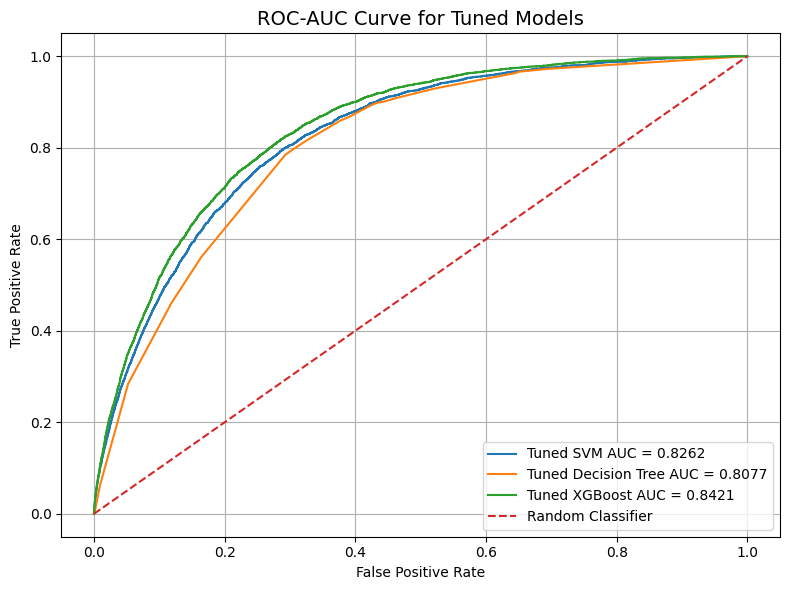

In [33]:
# ============================================================
# ROC-AUC CURVE FOR TUNED MODELS
# ============================================================

# Tuned models dictionary
tuned_models = {
    "Tuned SVM": best_svm,
    "Tuned Decision Tree": best_dt,
    "Tuned XGBoost": best_xgb
}

plt.figure(figsize=(8, 6))

for model_name, model in tuned_models.items():
    y_score = get_prediction_scores(model, X_test_scaled)

    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} AUC = {roc_auc:.4f}"
    )

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC-AUC Curve for Tuned Models", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()